# MobileNetV2 – Classificação CPRE (v5)

**Diagnóstico dos problemas persistentes:**
- Fase 1 val_F1 ≈ 0.15 em todas as versões → backbone congelado + OneCycleLR não funciona com este dataset
- `Biliary_Leaks` recall=0.18 → modelo ignora a classe mais rara apesar dos class weights

**Correções no v5:**

| Problema | Causa | Solução v5 |
|---|---|---|
| Fase 1 não aprende | OneCycleLR consome LR demasiado rápido | ReduceLROnPlateau (adapta ao progresso) |
| Biliary_Leaks recall baixo | CW_POWER=0.5 suavizou demais | Asymmetric loss: peso extra no recall das minorias |
| Fine-tuning lento | Descongelar tudo de uma vez | Descongelar gradualmente (última → primeira camada) |

In [1]:
!pip install -q livelossplot monai torchmetrics opencv-python-headless tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 30.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 13.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.13.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    raise RuntimeError('GPU não encontrada! Ativa em Settings > Accelerator > GPU T4 x2')

Dispositivo: cuda
GPU: Tesla T4


In [3]:
import os, cv2
from tqdm import tqdm

# Ajusta se necessário
INPUT_DIR  = '/kaggle/input/datasets/filipapereira30/dataset-2/MIQR-CC-Dataset/training/dataset'
OUTPUT_DIR = '/kaggle/working/dataset_clahe'

if os.path.exists(OUTPUT_DIR) and any(os.scandir(OUTPUT_DIR)):
    print(f'dataset_clahe já existe — a saltar.')
else:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    for split in ['train', 'val', 'test']:
        for cls in os.listdir(os.path.join(INPUT_DIR, split)):
            in_dir  = os.path.join(INPUT_DIR,  split, cls)
            out_dir = os.path.join(OUTPUT_DIR, split, cls)
            os.makedirs(out_dir, exist_ok=True)
            print(f'Processing {split}/{cls}...')
            for fname in tqdm(os.listdir(in_dir)):
                img = cv2.imread(os.path.join(in_dir, fname), cv2.IMREAD_GRAYSCALE)
                if img is None: continue
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
                cv2.imwrite(os.path.join(out_dir, fname), clahe.apply(img))
    print('CLAHE preprocessing completed.')

base_dir = OUTPUT_DIR
print(f'base_dir = {base_dir}')

Processing train/Stricture...


100%|██████████| 255/255 [00:07<00:00, 36.01it/s]


Processing train/Lithiasis...


100%|██████████| 505/505 [00:13<00:00, 38.17it/s]


Processing train/Biliary_Leaks...


...

Processing test/Biliary_Leaks...


100%|██████████| 17/17 [00:00<00:00, 38.20it/s]


Processing test/Normal...


100%|██████████| 43/43 [00:01<00:00, 29.79it/s]

CLAHE preprocessing completed.
base_dir = /kaggle/working/dataset_clahe


In [4]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random, time, warnings
warnings.filterwarnings('ignore')

from PIL import Image
from pathlib import Path
from datetime import datetime

from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, f1_score,
                              roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchmetrics.classification import MulticlassF1Score

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst,
                               Resize, RandZoom, RandAdjustContrast, RandGaussianNoise,
                               RandRotate, RandFlip, RandAffine, ToTensor, Compose,
                               NormalizeIntensity, Lambda)
from monai.data import decollate_batch
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

np.random.seed(0)
set_determinism(seed=0)
print_config()

2026-05-13 10:18:08.739360: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778667488.927277      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778667488.985951      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778667489.452982      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778667489.453034      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778667489.453037      57 computation_placer.cc:177] computation placer alr

MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.3
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.3.3
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#insta

In [5]:
model_path = '/kaggle/working/MIA_AP_my_models'
os.makedirs(model_path, exist_ok=True)

def get_versioned_model_name(base_path):
    base = Path(base_path)
    ts   = datetime.now().strftime('%Y%m%d_%H%M%S')
    return str(base.parent / f'{base.stem}_{ts}{base.suffix}')

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS_P1   = 15     # mais épocas na fase 1
EPOCHS_P2   = 60
LR_P1       = 3e-3   # LR mais alto para aprender mais depressa com backbone congelado
LR_P2       = 5e-5
PATIENCE    = 15
SEED        = 42

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f'Config OK | LR_P1={LR_P1} | LR_P2={LR_P2} | EPOCHS_P1={EPOCHS_P1}')

Config OK | LR_P1=0.003 | LR_P2=5e-05 | EPOCHS_P1=15


In [6]:
phases = ['train', 'val', 'test']
data   = {phase: {'images': [], 'labels': []} for phase in phases}

class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, 'train'))
    if os.path.isdir(os.path.join(base_dir, 'train', x))
])
num_class = len(class_names)
print(f'Classes ({num_class}): {class_names}')

valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
for phase in phases:
    for i, cname in enumerate(class_names):
        cdir = os.path.join(base_dir, phase, cname)
        imgs = [os.path.join(cdir, f) for f in os.listdir(cdir) if f.lower().endswith(valid_exts)]
        data[phase]['images'].extend(imgs)
        data[phase]['labels'].extend([i] * len(imgs))

for phase in phases:
    labels = data[phase]['labels']
    print(f'\n{phase.upper()} – {len(labels)} imagens')
    for i, c in enumerate(class_names):
        n = labels.count(i)
        print(f'  {c}: {n} ({100*n/len(labels):.1f}%)')

Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']

TRAIN – 1067 imagens
  Biliary_Leaks: 110 (10.3%)
  Lithiasis: 505 (47.3%)
  Normal: 197 (18.5%)
  Stricture: 255 (23.9%)

VAL – 234 imagens
  Biliary_Leaks: 24 (10.3%)
  Lithiasis: 98 (41.9%)
  Normal: 59 (25.2%)
  Stricture: 53 (22.6%)

TEST – 267 imagens
  Biliary_Leaks: 17 (6.4%)
  Lithiasis: 123 (46.1%)
  Normal: 43 (16.1%)
  Stricture: 84 (31.5%)


In [8]:
def repeat_if_needed(img):
    return img.repeat(3, 1, 1) if img.shape[0] == 1 else img

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    RandFlip(spatial_axis=0, prob=0.4),
    RandFlip(spatial_axis=1, prob=0.4),
    RandRotate(range_x=20, prob=0.5),
    RandZoom(min_zoom=0.85, max_zoom=1.15, prob=0.5),
    RandAffine(shear_range=0.1, prob=0.3),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.02),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act       = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)
print('Transforms definidos.')

Transforms definidos.


In [9]:
class ERCPDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels      = labels
        self.transforms  = transforms
    def __len__(self): return len(self.image_files)
    def __getitem__(self, idx):
        return self.transforms(self.image_files[idx]), self.labels[idx]


# ── Class weights COMPLETOS (sem suavização) ──────────────────────────────────
# A suavização CW_POWER=0.5 estava a reduzir demasiado o peso de Biliary_Leaks
# Voltamos aos pesos completos mas compensamos com FocalLoss em vez de CE
train_labels_np = np.array(data['train']['labels'])
cw = compute_class_weight('balanced', classes=np.arange(num_class), y=train_labels_np)
cw_tensor = torch.tensor(cw, dtype=torch.float32).to(device)
print('Class weights:')
for i, w in enumerate(cw):
    print(f'  {class_names[i]}: {w:.3f}')

train_ds = ERCPDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds   = ERCPDataset(data['val']['images'],   data['val']['labels'],   val_transforms)
test_ds  = ERCPDataset(data['test']['images'],  data['test']['labels'],  val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'\nTrain: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Class weights:
  Biliary_Leaks: 2.425
  Lithiasis: 0.528
  Normal: 1.354
  Stricture: 1.046

Train: 1067 | Val: 234 | Test: 267


## Loss – NOVO: Focal Loss com class weights

A **Focal Loss** penaliza mais os exemplos difíceis (como Biliary_Leaks) e menos os fáceis já bem classificados. Combinada com class weights, resolve o baixo recall nas classes raras.

In [10]:
class FocalLossWithWeights(nn.Module):
    """
    Focal Loss com class weights.
    gamma=2 penaliza exemplos fáceis, forcing o modelo a focar nos difíceis.
    """
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs, targets,
            weight=self.weight,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        pt      = torch.exp(-ce_loss)
        focal   = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()


loss_fn = FocalLossWithWeights(weight=cw_tensor, gamma=2.0, label_smoothing=0.1)
print('Loss: FocalLoss (gamma=2, class weights, label_smoothing=0.1)')


def mixup_data(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1-lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1-lam) * criterion(pred, y_b)

Loss: FocalLoss (gamma=2, class weights, label_smoothing=0.1)


In [11]:
def build_model(freeze_backbone=True):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_class)
    )
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    return model.to(device)

model     = build_model(freeze_backbone=True)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros treináveis (fase 1): {trainable:,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 117MB/s] 

Parâmetros treináveis (fase 1): 328,964


In [32]:
def train_phase(model, train_dl, val_dl, optimizer, scheduler,
                epochs, save_path, patience, use_mixup=False,
                phase_name='', scheduler_on_plateau=False):

    f1_metric  = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    auc_metric = ROCAUCMetric()
    #liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f'/kaggle/working/{phase_name}.png')]) # liveloss removido
    best_f1, best_epoch, no_improve = -1.0, -1, 0

    print(f'\n{"="*55}')
    print(f' {phase_name}  |  epochs={epochs}  |  mixup={use_mixup}')
    print(f'{"="*55}')

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        y_pred_all = torch.tensor([], dtype=torch.float32, device=device)
        y_all      = torch.tensor([], dtype=torch.long,    device=device)

        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            if use_mixup:
                inputs, y_a, y_b, lam = mixup_data(inputs, labels)
                outputs = model(inputs)
                loss    = mixup_criterion(loss_fn, outputs, y_a, y_b, lam)
            else:
                outputs = model(inputs)
                loss    = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.detach() * inputs.size(0)
            y_pred_all = torch.cat([y_pred_all, outputs.detach()], dim=0)
            y_all      = torch.cat([y_all, labels], dim=0)

        epoch_loss = (running_loss / len(train_dl.dataset)).item()
        train_f1   = f1_metric(y_pred_all.argmax(dim=1), y_all).item()

        model.eval()
        val_loss = 0.0
        y_pred_v = torch.tensor([], dtype=torch.float32, device=device)
        y_v      = torch.tensor([], dtype=torch.long,    device=device)

        with torch.no_grad():
            for inputs, labels in val_dl:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs  = model(inputs)
                val_loss += loss_fn(outputs, labels).detach() * inputs.size(0)
                y_pred_v  = torch.cat([y_pred_v, outputs], dim=0)
                y_v       = torch.cat([y_v, labels],       dim=0)

        val_epoch_loss = (val_loss / len(val_dl.dataset)).item()
        val_f1         = f1_metric(y_pred_v.argmax(dim=1), y_v).item()

        y_onehot   = [to_onehot(i) for i in decollate_batch(y_v, detach=False)]
        y_pred_act = [act(i) for i in decollate_batch(y_pred_v)]
        auc_metric(y_pred_act, y_onehot)
        auc_val = auc_metric.aggregate()
        auc_metric.reset()

        # ReduceLROnPlateau precisa da métrica; os outros fazem step() simples
        if scheduler_on_plateau:
            scheduler.step(val_f1)
        else:
            scheduler.step()

        print(f'Ep {epoch+1:3d}/{epochs}  loss={epoch_loss:.4f}  '
              f'val_loss={val_epoch_loss:.4f}  F1={train_f1:.4f}  '
              f'val_F1={val_f1:.4f}  AUC={auc_val:.4f}  '
              f'LR={optimizer.param_groups[0]["lr"]:.2e}')

        if val_f1 > best_f1:
            best_f1, best_epoch = val_f1, epoch+1
            torch.save(model.state_dict(), save_path)
            print(f'  ✔ Melhor modelo guardado (val F1={best_f1:.4f})')
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f'Early stopping ep {epoch+1}. Melhor: {best_epoch}, F1={best_f1:.4f}')
            break

    print(f'Fase concluída – melhor val F1: {best_f1:.4f}')
    return best_f1

## Fase 1 – Feature Extraction

**NOVO:** `ReduceLROnPlateau` adapta o LR ao progresso real do val_F1, em vez de seguir um schedule fixo. Assim se o modelo parar de aprender, o LR baixa automaticamente.

In [34]:
set_seed(SEED)
model      = build_model(freeze_backbone=True)
model_name = get_versioned_model_name(f'{model_path}/mobilenet_v2_v5.pth')

opt1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_P1, weight_decay=1e-4
)
# ReduceLROnPlateau: reduz LR por fator 0.5 se val_F1 não melhorar em 4 épocas
sch1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt1, mode='max', factor=0.5, patience=4, min_lr=1e-6
)

t0 = time.perf_counter()
train_phase(model, train_loader, val_loader,
            opt1, sch1, EPOCHS_P1, model_name,
            patience=PATIENCE, use_mixup=False,
            phase_name='Fase1_FeatureExtraction',
            scheduler_on_plateau=True)
print(f'Tempo fase 1: {time.perf_counter()-t0:.1f}s')


 Fase1_FeatureExtraction  |  epochs=15  |  mixup=False
Ep   1/15  loss=0.9192  val_loss=0.9130  F1=0.1863  val_F1=0.0534  AUC=0.6101  LR=3.00e-03
  ✔ Melhor modelo guardado (val F1=0.0534)
Ep   2/15  loss=0.8632  val_loss=0.9015  F1=0.2012  val_F1=0.2524  AUC=0.6202  LR=3.00e-03
  ✔ Melhor modelo guardado (val F1=0.2524)
Ep   3/15  loss=0.8421  val_loss=0.9487  F1=0.2402  val_F1=0.1939  AUC=0.6219  LR=3.00e-03
Ep   4/15  loss=0.8306  val_loss=0.9074  F1=0.2180  val_F1=0.2677  AUC=0.6068  LR=3.00e-03
  ✔ Melhor modelo guardado (val F1=0.2677)
Ep   5/15  loss=0.8115  val_loss=0.9147  F1=0.2675  val_F1=0.1541  AUC=0.6257  LR=3.00e-03
Ep   6/15  loss=0.8191  val_loss=0.8763  F1=0.2480  val_F1=0.2744  AUC=0.6260  LR=3.00e-03
  ✔ Melhor modelo guardado (val F1=0.2744)
Ep   7/15  loss=0.8101  val_loss=0.8691  F1=0.2227  val_F1=0.3071  AUC=0.6665  LR=3.00e-03
  ✔ Melhor modelo guardado (val F1=0.3071)
Ep   8/15  loss=0.7681  val_loss=0.8857  F1=0.2838  val_F1=0.2670  AUC=0.6237  LR=3.00e-03
E

## Fase 2 – Fine-tuning Gradual

**NOVO:** Em vez de descongelar todo o backbone de uma vez, descongelamos gradualmente:
- Primeiro as últimas 5 camadas
- Depois toda a rede

Isto evita que os gradientes das primeiras camadas destruam os pesos aprendidos.

In [35]:
# ── Fase 2a: descongelar só as últimas 5 camadas do backbone ─────────────────
model.load_state_dict(torch.load(model_name))

# Descongela últimas 5 camadas
layers = list(model.features.children())
for layer in layers[-5:]:
    for param in layer.parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Fase 2a: {trainable:,} parâmetros treináveis (últimas 5 camadas)')

opt2a = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_P2 * 2, weight_decay=1e-4
)
sch2a = torch.optim.lr_scheduler.CosineAnnealingLR(opt2a, T_max=20, eta_min=1e-7)

t0 = time.perf_counter()
train_phase(model, train_loader, val_loader,
            opt2a, sch2a, 20, model_name,
            patience=8, use_mixup=True,
            phase_name='Fase2a_PartialFineTune',
            scheduler_on_plateau=False)
print(f'Tempo fase 2a: {time.perf_counter()-t0:.1f}s')

Fase 2a: 2,010,308 parâmetros treináveis (últimas 5 camadas)

 Fase2a_PartialFineTune  |  epochs=20  |  mixup=True
Ep   1/20  loss=0.7808  val_loss=0.8284  F1=0.2290  val_F1=0.3207  AUC=0.6648  LR=9.94e-05
  ✔ Melhor modelo guardado (val F1=0.3207)
Ep   2/20  loss=0.7689  val_loss=0.8501  F1=0.2504  val_F1=0.2906  AUC=0.6589  LR=9.76e-05
Ep   3/20  loss=0.7578  val_loss=0.8485  F1=0.2769  val_F1=0.2905  AUC=0.6680  LR=9.46e-05
Ep   4/20  loss=0.7628  val_loss=0.8455  F1=0.2685  val_F1=0.3320  AUC=0.6822  LR=9.05e-05
  ✔ Melhor modelo guardado (val F1=0.3320)
Ep   5/20  loss=0.7213  val_loss=0.8622  F1=0.2764  val_F1=0.2756  AUC=0.6686  LR=8.54e-05
Ep   6/20  loss=0.7314  val_loss=0.8533  F1=0.2341  val_F1=0.3471  AUC=0.6807  LR=7.94e-05
  ✔ Melhor modelo guardado (val F1=0.3471)
Ep   7/20  loss=0.6890  val_loss=0.8586  F1=0.2634  val_F1=0.2969  AUC=0.6816  LR=7.27e-05
Ep   8/20  loss=0.6758  val_loss=0.8467  F1=0.3030  val_F1=0.3297  AUC=0.6923  LR=6.55e-05
Ep   9/20  loss=0.6934  val_

In [36]:
# ── Fase 2b: descongelar TUDO com LR muito baixo ─────────────────────────────
model.load_state_dict(torch.load(model_name))
for param in model.parameters():
    param.requires_grad = True
print(f'Fase 2b: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} parâmetros (todos)')

opt2b = torch.optim.AdamW(model.parameters(), lr=LR_P2, weight_decay=1e-4)
sch2b = torch.optim.lr_scheduler.CosineAnnealingLR(opt2b, T_max=EPOCHS_P2, eta_min=1e-7)

t0 = time.perf_counter()
train_phase(model, train_loader, val_loader,
            opt2b, sch2b, EPOCHS_P2, model_name,
            patience=PATIENCE, use_mixup=True,
            phase_name='Fase2b_FullFineTune',
            scheduler_on_plateau=False)
print(f'Tempo fase 2b: {time.perf_counter()-t0:.1f}s')

Fase 2b: 2,552,836 parâmetros (todos)

 Fase2b_FullFineTune  |  epochs=60  |  mixup=True
Ep   1/60  loss=0.6992  val_loss=0.8337  F1=0.3111  val_F1=0.3219  AUC=0.6912  LR=5.00e-05
  ✔ Melhor modelo guardado (val F1=0.3219)
Ep   2/60  loss=0.7044  val_loss=0.8310  F1=0.3007  val_F1=0.3224  AUC=0.6998  LR=4.99e-05
  ✔ Melhor modelo guardado (val F1=0.3224)
Ep   3/60  loss=0.6587  val_loss=0.8290  F1=0.2728  val_F1=0.3119  AUC=0.6983  LR=4.97e-05
Ep   4/60  loss=0.6884  val_loss=0.8267  F1=0.2754  val_F1=0.3191  AUC=0.6996  LR=4.95e-05
Ep   5/60  loss=0.6468  val_loss=0.8406  F1=0.2880  val_F1=0.3002  AUC=0.6989  LR=4.91e-05
Ep   6/60  loss=0.6664  val_loss=0.8360  F1=0.2789  val_F1=0.3233  AUC=0.7036  LR=4.88e-05
  ✔ Melhor modelo guardado (val F1=0.3233)
Ep   7/60  loss=0.6607  val_loss=0.8350  F1=0.2936  val_F1=0.3378  AUC=0.7097  LR=4.83e-05
  ✔ Melhor modelo guardado (val F1=0.3378)
Ep   8/60  loss=0.6323  val_loss=0.8261  F1=0.3599  val_F1=0.3347  AUC=0.7121  LR=4.78e-05
Ep   9/60  

In [37]:
model.load_state_dict(torch.load(model_name))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(device))
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(np.argmax(probs, axis=1))
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

f1  = f1_score(all_labels, all_preds, average='macro')
acc = accuracy_score(all_labels, all_preds)

print(f'\n{"="*55}')
print(f' Accuracy  : {acc:.4f}')
print(f' F1-macro  : {f1:.4f}')
print(f' Baseline  : 0.7380')
print(f' Delta     : {f1-0.738:+.4f}')
print(f'{"="*55}\n')
print(classification_report(all_labels, all_preds,
                             target_names=class_names, digits=4, zero_division=0))


 Accuracy  : 0.4607
 F1-macro  : 0.4112
 Baseline  : 0.7380
 Delta     : -0.3268

               precision    recall  f1-score   support

Biliary_Leaks     0.2727    0.1765    0.2143        17
    Lithiasis     0.5714    0.2602    0.3575       123
       Normal     0.3482    0.9070    0.5032        43
    Stricture     0.5568    0.5833    0.5698        84

     accuracy                         0.4607       267
    macro avg     0.4373    0.4817    0.4112       267
 weighted avg     0.5119    0.4607    0.4387       267



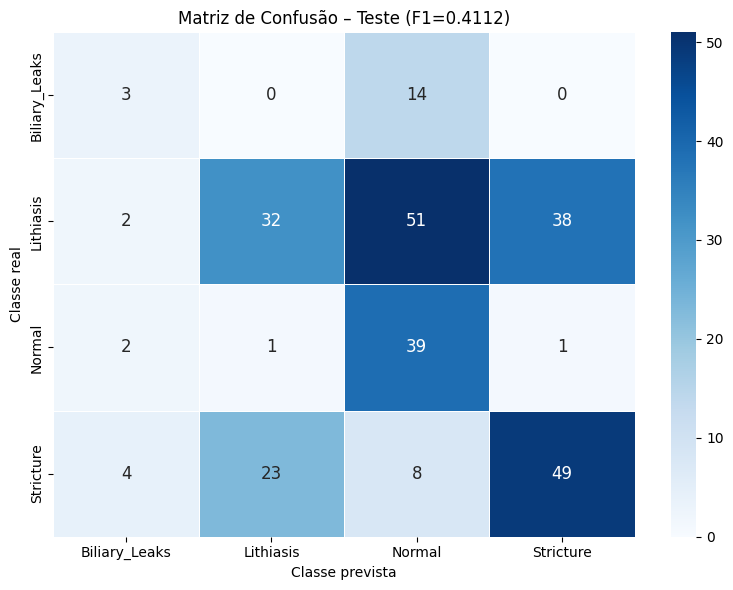

In [38]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 12})
plt.ylabel('Classe real'); plt.xlabel('Classe prevista')
plt.title(f'Matriz de Confusão – Teste (F1={f1:.4f})')
plt.tight_layout()
plt.savefig(f'{model_path}/confusion_matrix.png', dpi=200)
plt.show()

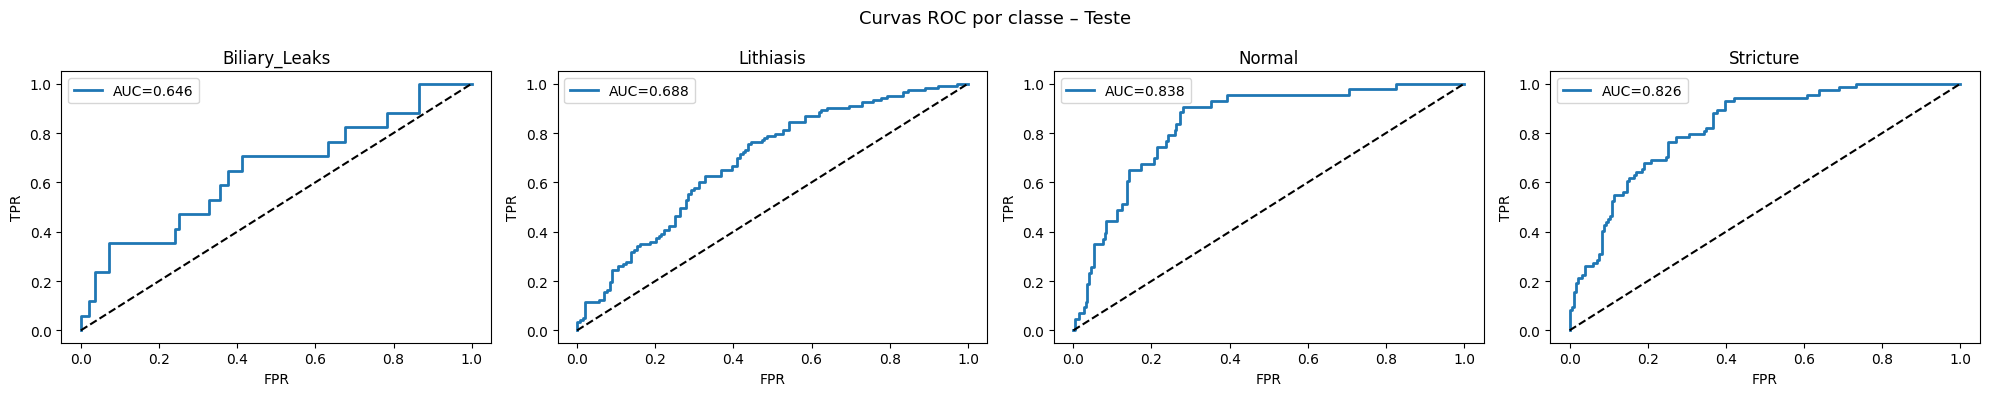

AUC-ROC macro (OvR): 0.7494


In [39]:
y_bin = label_binarize(all_labels, classes=np.arange(num_class))
fig, axes = plt.subplots(1, num_class, figsize=(5*num_class, 4))
for i, (ax, cname) in enumerate(zip(axes, class_names)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_val = roc_auc_score(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, lw=2, label=f'AUC={auc_val:.3f}')
    ax.plot([0,1],[0,1],'k--'); ax.set_title(cname)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend()
plt.suptitle('Curvas ROC por classe – Teste', fontsize=13)
plt.tight_layout()
plt.savefig(f'{model_path}/roc_curves.png', dpi=150)
plt.show()
mean_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
print(f'AUC-ROC macro (OvR): {mean_auc:.4f}')

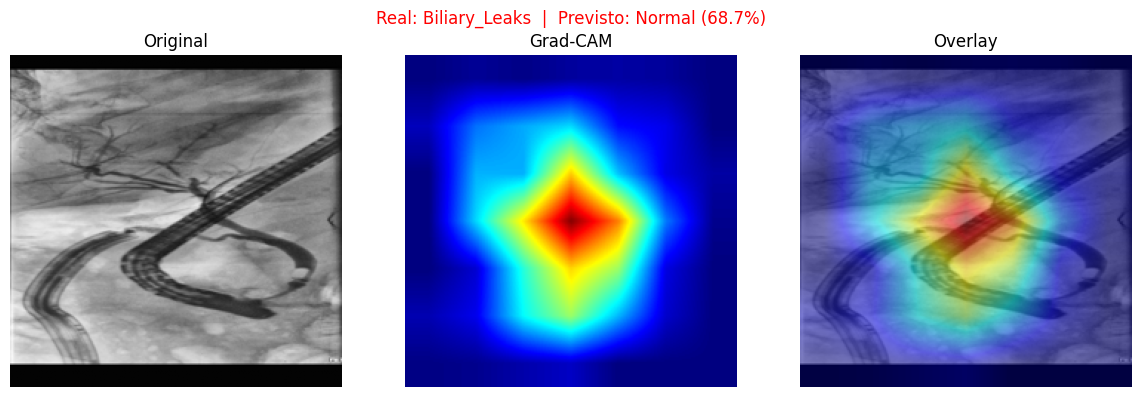

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_0.png


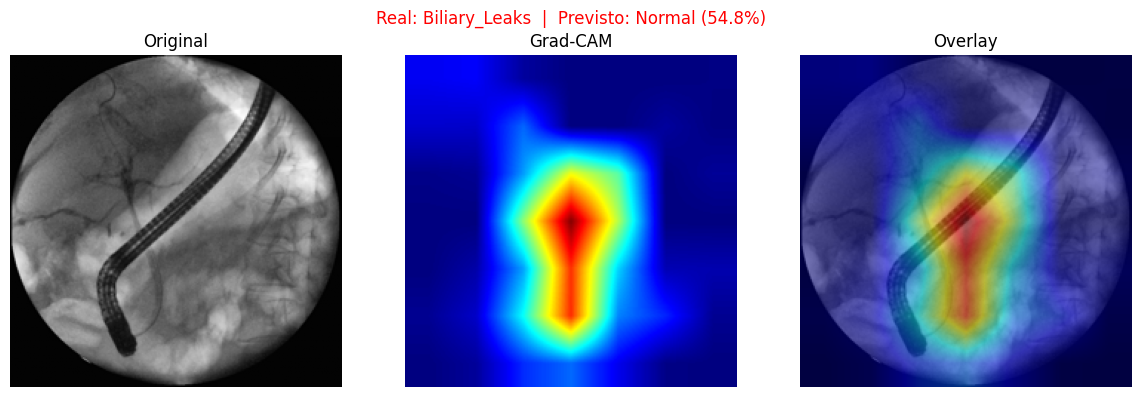

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_1.png


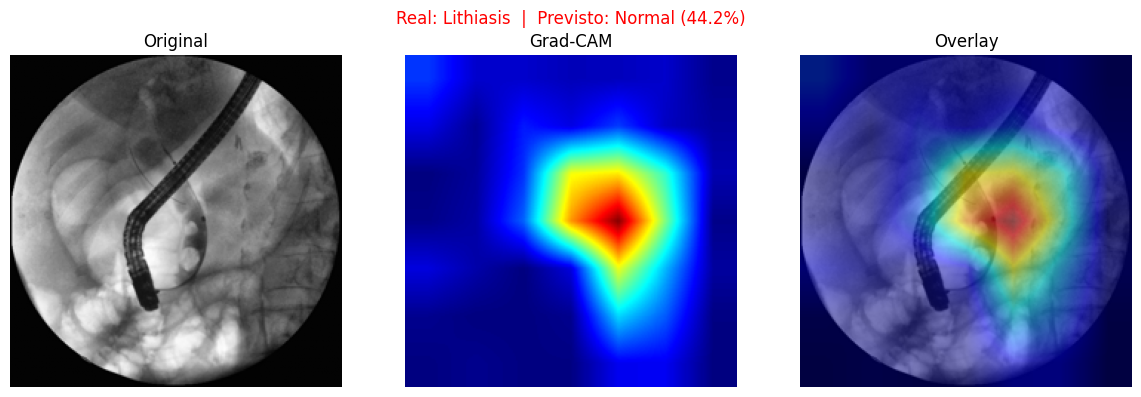

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_0.png


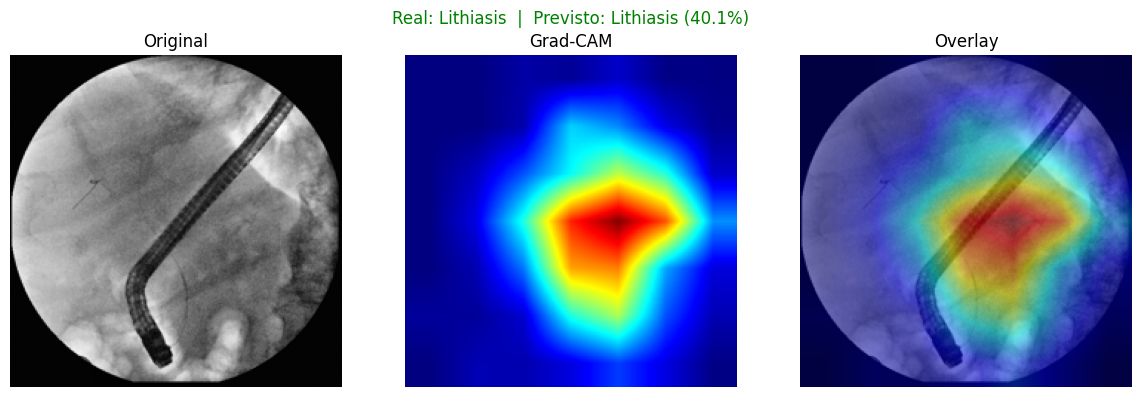

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_1.png


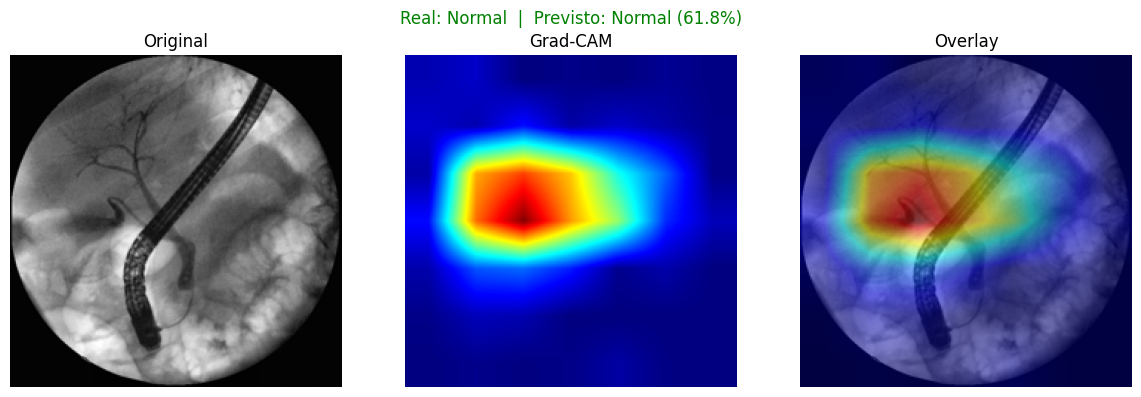

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_0.png


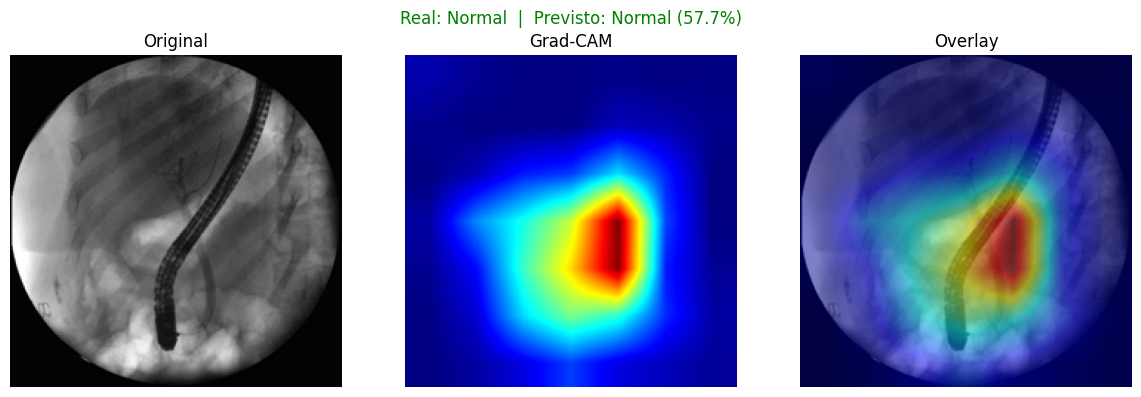

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_1.png


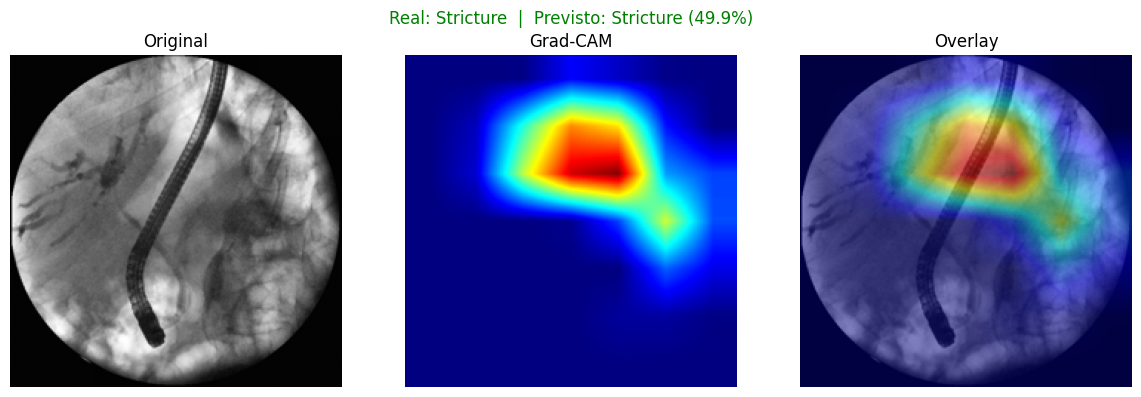

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_0.png


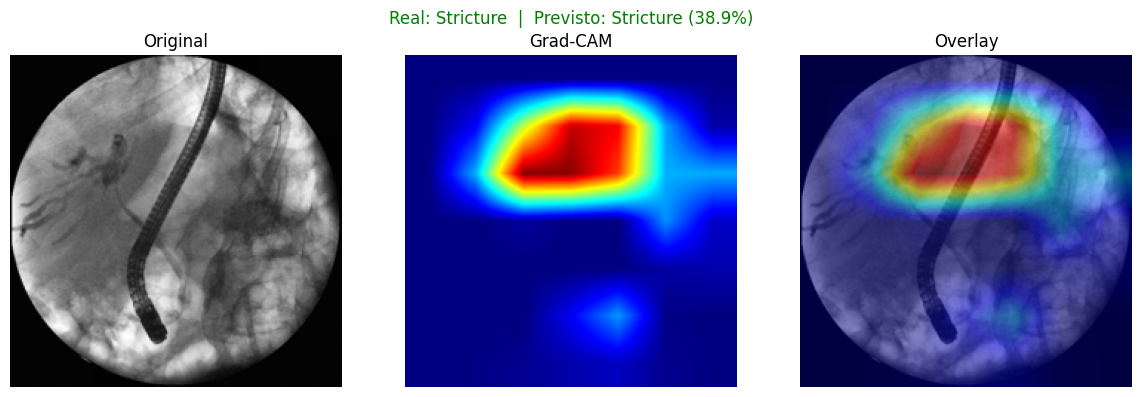

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_1.png


In [40]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        x   = input_tensor.unsqueeze(0).to(device).requires_grad_(True)
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        self.model.zero_grad()
        oh = torch.zeros_like(out); oh[0, class_idx] = 1.0
        out.backward(gradient=oh)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx, F.softmax(out, dim=1)[0, class_idx].item()

gradcam = GradCAM(model, target_layer=model.features[-1])

def show_gradcam(img_path, true_label, save_path=None):
    img_tensor = val_transforms(img_path)
    cam, pred_idx, prob = gradcam.generate(img_tensor)
    raw     = np.array(Image.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE)))
    raw_rgb = cv2.cvtColor(raw, cv2.COLOR_GRAY2RGB)
    cam_r   = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap((cam_r*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5*raw_rgb + 0.5*heatmap).astype(np.uint8)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw, cmap='gray'); axes[0].set_title('Original');  axes[0].axis('off')
    axes[1].imshow(heatmap);          axes[1].set_title('Grad-CAM');  axes[1].axis('off')
    axes[2].imshow(overlay);          axes[2].set_title('Overlay');   axes[2].axis('off')
    cor = 'green' if pred_idx == true_label else 'red'
    plt.suptitle(f'Real: {class_names[true_label]}  |  Previsto: {class_names[pred_idx]} ({prob:.1%})',
                 fontsize=12, color=cor)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=200)
    plt.show()

os.makedirs(f'{model_path}/gradcam', exist_ok=True)
for ci, cname in enumerate(class_names):
    imgs = [(p,l) for p,l in zip(data['test']['images'], data['test']['labels']) if l == ci]
    for k, (path, lbl) in enumerate(imgs[:2]):
        save_file = f'{model_path}/gradcam/gradcam_{cname}_{k}.png'
        show_gradcam(path, lbl, save_path=save_file)
        print(f'Guardado: {save_file}')

In [41]:
print('='*60)
print('RESUMO COMPARATIVO')
print('='*60)
print(f'  v0 (professor, CPU)  test F1 = 0.4564')
print(f'  v1 (CPU)             test F1 = 0.4973')
print(f'  v2 (GPU, colapso)    test F1 = 0.3063')
print(f'  v3 (GPU)             test F1 = 0.4771')
print(f'  v4 (CLAHE offline)   test F1 = 0.5558')
print(f'  v5 (FocalLoss+grad.) test F1 = {f1:.4f}')
print(f'  Baseline artigo              = 0.7380')
print(f'  Delta vs baseline            = {f1-0.738:+.4f}')
print('='*60)

RESUMO COMPARATIVO
  v0 (professor, CPU)  test F1 = 0.4564
  v1 (CPU)             test F1 = 0.4973
  v2 (GPU, colapso)    test F1 = 0.3063
  v3 (GPU)             test F1 = 0.4771
  v4 (CLAHE offline)   test F1 = 0.5558
  v5 (FocalLoss+grad.) test F1 = 0.4112
  Baseline artigo              = 0.7380
  Delta vs baseline            = -0.3268
